## Imports Section:

In [1]:
import numpy as np
import pandas as pd
import random
import scipy
from scipy import stats
import datetime as dt
import dask.dataframe as dd

In [2]:
import librosa
import warnings

In [3]:
import glob
import matplotlib.pyplot as plt
from matplotlib import colors
import soundfile as sf
import matplotlib.patches as patches
from pathlib import Path

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm

In [5]:
import sys

# append the path of the
# parent directory
sys.path.append('..')
sys.path.append('../src/')
sys.path.append('../src/models/bat_call_detector/batdetect2/')

import src.batdt2_pipeline as batdetect2_pipeline
import src.file_dealer as file_dealer

## Function Definitions (most important functions are in `src/`)
### Below are the functions used for plotting and visualization

In [6]:
def convert_bd2df_ravenpro(df: pd.DataFrame):
    """
    Converts a dataframe to the format used by RavenPro
    """

    ravenpro_df = df.copy()

    ravenpro_df.rename(columns={
        "start_time": "Begin Time (s)",
        "end_time": "End Time (s)",
        "low_freq": "Low Freq (Hz)",
        "high_freq": "High Freq (Hz)",
        "event": "Annotation",
        "freq_group":"Manually-Verified Phonic Group",
        'snr_nist_quick_dB':'SNR NIST Quick (dB)',
        'delta_time_s':'Delta Time (s)'
    }, inplace=True)

    ravenpro_df["Selection"] = np.arange(0, df.shape[0]).astype('int') + 1
    ravenpro_df["View"] = "Waveform 1"
    ravenpro_df["Channel"] = "1"

    return ravenpro_df

In [7]:
FREQ_COLORS = {'LF':'cyan', 'HF':'orange'}

In [8]:
file_sites = {'20220730_053000':'Carp',
 '20220826_070000':'Central',
 '20220727_083000':'Foliage',
 '20220829_090000':'Foliage'}
bd2_dets_save_dir = Path(f'20250115__group_threshold_sweep_results')
raventxt_human_files_dir = f'{Path.home()}/Documents/Research/mila_files/mila-human-wav-txt'
extension = ".txt"
sep = "\t"

SITE_NAMES = {'Carp':'Carp Pond', 'Foliage':'Foliage', 'Central':'Central Pond'}

file_keys = list(file_sites.keys())
file_keys

['20220730_053000', '20220826_070000', '20220727_083000', '20220829_090000']

In [9]:
def return_confusion_matrix_from_comparing_two_detectors(human_df, machine_df):
    false_positives = 0 ## machine made detection that human did not make
    true_positives = 0  ## machine made detection that human made
    true_negatives = 0  ## machine did not make detection that human also did not make
    false_negatives = 0 ## machine did not make detection that human made
    human_ind = 0
    machine_ind = 0

    while (human_ind < len(human_df))&(machine_ind < len(machine_df)):
        human_det = human_df.iloc[human_ind]
        machine_det = machine_df.iloc[machine_ind]
        human_start_time = human_det['peak_frequency_time'] - 0.005
        human_end_time = human_det['peak_frequency_time'] + 0.005
        human_low_freq = human_det['low_freq']
        human_high_freq = human_det['high_freq']

        machine_start_time = machine_det['peak_frequency_time_SPECTROGRAM'] - 0.005
        machine_end_time = machine_det['peak_frequency_time_SPECTROGRAM'] + 0.005
        machine_low_freq = machine_det['low_freq']
        machine_high_freq = machine_det['high_freq']

        machine_det_start_in_human_det_bounds = ((machine_start_time>=human_start_time)&(machine_start_time<=human_end_time))
        machine_det_end_in_human_det_bounds = ((machine_end_time>=human_start_time)&(machine_end_time<=human_end_time))
        human_det_start_in_machine_det_bounds = ((human_start_time>=machine_start_time)&(human_start_time<=machine_end_time))
        human_det_end_in_machine_det_bounds = ((human_end_time>=machine_start_time)&(human_end_time<=machine_end_time))
        machine_det_time_in_human_bounds = machine_det_start_in_human_det_bounds|machine_det_end_in_human_det_bounds
        human_det_time_in_machine_bounds = human_det_start_in_machine_det_bounds|human_det_end_in_machine_det_bounds

        machine_det_low_in_human_det_bounds = ((machine_low_freq>=human_low_freq)&(machine_low_freq<=human_high_freq))
        machine_det_high_in_human_det_bounds = ((machine_high_freq>=human_low_freq)&(machine_high_freq<=human_high_freq))
        human_det_low_in_machine_det_bounds = ((human_low_freq>=machine_low_freq)&(human_low_freq<=machine_high_freq))
        human_det_high_in_machine_det_bounds = ((human_high_freq>=machine_low_freq)&(human_high_freq<=machine_high_freq))
        machine_det_freq_in_human_bounds = machine_det_low_in_human_det_bounds|machine_det_high_in_human_det_bounds
        human_det_freq_in_machine_bounds = human_det_low_in_machine_det_bounds|human_det_high_in_machine_det_bounds

        machine_det_time_matches_human_time = (machine_det_time_in_human_bounds|human_det_time_in_machine_bounds)
        machine_det_freq_matches_human_time = (machine_det_freq_in_human_bounds|human_det_freq_in_machine_bounds)
        machine_detection_corresponds_to_human = machine_det_time_matches_human_time&machine_det_freq_matches_human_time

        if (machine_detection_corresponds_to_human):
            true_positives += 1
            machine_ind+=1
            human_ind+=1
        else:
            ## Machine detection is referring to call not detected by human (thus, it detected a non-bat call)
            false_positive_same_group_before_human_det = (machine_end_time<=human_start_time)&(machine_det_freq_matches_human_time)
            false_positive_diff_group_before_human_det = (machine_start_time<=human_start_time)&(~machine_det_freq_matches_human_time)

            false_negative_same_group_before_human_det = (machine_start_time>human_end_time)&(machine_det_freq_matches_human_time)
            false_negative_diff_group_before_human_det = (machine_start_time>human_start_time)&(~machine_det_freq_matches_human_time)

            if (false_positive_same_group_before_human_det|false_positive_diff_group_before_human_det):
                false_positives += 1
                machine_ind+=1
            ## Machine has skipped a human-annotated call in detection (thus, it did not detect a bat call)
            elif (false_negative_same_group_before_human_det|false_negative_diff_group_before_human_det):
                false_negatives += 1
                human_ind+=1
            else:
                true_negatives += 1

    if (machine_ind<len(machine_df)):
        false_positives += (len(machine_df) - (machine_ind))
    if (human_ind<len(human_df)):
        false_negatives += (len(human_df) - (human_ind))

    assert((true_positives+false_negatives)==len(human_df))
    assert((false_positives+true_positives)==len(machine_df))

    return {'true_positives':true_positives, 'false_positives':false_positives, 'false_negatives':false_negatives, 'true_negatives':true_negatives}

## Following the confusion matrix structure shown below

![image](example_confusion_matrix.png)

In [10]:
def get_precision_and_recall_from_metrics(true_positives, false_positives, false_negatives):
    denom_precision = (true_positives + false_positives)
    denom_recall = (true_positives + false_negatives)
    if (denom_precision>0):
        precision = true_positives / denom_precision
    else:
        precision = np.NaN
    if (denom_recall>0):
        recall = true_positives / denom_recall
    else:
        recall = np.NaN
    
    return precision, recall

In [11]:
def gather_evaluation_results_between_bd2_and_human(bd2_human_df, batdetect2_df_thresh):
    file_batdetect2_cf = return_confusion_matrix_from_comparing_two_detectors(bd2_human_df, batdetect2_df_thresh)
    precision, recall = get_precision_and_recall_from_metrics(file_batdetect2_cf['true_positives'], 
                                                              file_batdetect2_cf['false_positives'], 
                                                              file_batdetect2_cf['false_negatives'])

    return file_batdetect2_cf, precision, recall

In [12]:
def apply_SNR_threshold_on_both_sets(bd2_human_df, batdetect2_df, SNR_thresh):
    bd2_human_df_SNR = bd2_human_df[bd2_human_df['adityas_method_snr_dB']>=SNR_thresh].copy()
    batdetect2_df_SNR = batdetect2_df[batdetect2_df['SNR']>=SNR_thresh].copy()

    return bd2_human_df_SNR, batdetect2_df_SNR

In [13]:
def make_new_row_in_eval_df(file_batdetect2_cf, precision, recall):
    row = pd.DataFrame([file_batdetect2_cf])
    row['precision'] = precision
    row['recall'] = recall

    return row

In [14]:
def generate_evaluation_df(bd2_human_df, batdetect2_df):
    batdetect2_eval = pd.DataFrame()

    increment = 2.0
    snr_thresholds = np.arange(0, 22+increment, increment)
    for snr_thresh in snr_thresholds:
        bd2_human_df_SNR, batdetect2_df_SNR = apply_SNR_threshold_on_both_sets(bd2_human_df, batdetect2_df, snr_thresh)

        increment = 0.01
        detection_thresholds = np.arange(0.05, 0.6+increment, increment)
        for det_thresh in detection_thresholds:
            det_thresh = round(det_thresh, 2)
            print(snr_thresh, det_thresh)
            batdetect2_df_SNR_detthresh = batdetect2_df_SNR[batdetect2_df_SNR['det_prob']>=det_thresh].copy()
            file_batdetect2_cf, precision, recall = gather_evaluation_results_between_bd2_and_human(bd2_human_df_SNR, 
                                                                                                    batdetect2_df_SNR_detthresh)
            row = make_new_row_in_eval_df(file_batdetect2_cf, precision, recall)
            row.insert(0, 'num_human_annotations', [len(bd2_human_df_SNR)])
            row.insert(0, 'num_bd2_detections', [len(batdetect2_df_SNR_detthresh)])
            row.insert(0, 'detection_threshold', [det_thresh])
            row.insert(0, 'SNR_threshold', [snr_thresh])
            batdetect2_eval = pd.concat([batdetect2_eval, row])
            assert(len(batdetect2_df_SNR_detthresh['freq_group'].unique())<=2)

    batdetect2_eval.reset_index(drop=True, inplace=True)
    return batdetect2_eval

In [15]:
def return_true_positives_using_human_df(human_df, machine_df, debug=True):
    false_positives = 0 ## machine made detection that human did not make
    true_positives = 0  ## machine made detection that human made
    true_negatives = 0  ## machine did not make detection that human also did not make
    false_negatives = 0 ## machine did not make detection that human made
    human_ind = 0
    machine_ind = 0

    true_positives_df = pd.DataFrame()
    while (human_ind < len(human_df))&(machine_ind < len(machine_df)):
        human_det = human_df.iloc[human_ind]
        machine_det = machine_df.iloc[machine_ind]
        human_start_time = human_det['peak_frequency_time'] - 0.005
        human_end_time = human_det['peak_frequency_time'] + 0.005
        human_low_freq = human_det['low_freq']
        human_high_freq = human_det['high_freq']

        machine_start_time = machine_det['peak_frequency_time_SPECTROGRAM'] - 0.005
        machine_end_time = machine_det['peak_frequency_time_SPECTROGRAM'] + 0.005
        machine_low_freq = machine_det['low_freq']
        machine_high_freq = machine_det['high_freq']

        machine_det_start_in_human_det_bounds = ((machine_start_time>=human_start_time)&(machine_start_time<=human_end_time))
        machine_det_end_in_human_det_bounds = ((machine_end_time>=human_start_time)&(machine_end_time<=human_end_time))
        human_det_start_in_machine_det_bounds = ((human_start_time>=machine_start_time)&(human_start_time<=machine_end_time))
        human_det_end_in_machine_det_bounds = ((human_end_time>=machine_start_time)&(human_end_time<=machine_end_time))
        machine_det_time_in_human_bounds = machine_det_start_in_human_det_bounds|machine_det_end_in_human_det_bounds
        human_det_time_in_machine_bounds = human_det_start_in_machine_det_bounds|human_det_end_in_machine_det_bounds

        machine_det_low_in_human_det_bounds = ((machine_low_freq>=human_low_freq)&(machine_low_freq<=human_high_freq))
        machine_det_high_in_human_det_bounds = ((machine_high_freq>=human_low_freq)&(machine_high_freq<=human_high_freq))
        human_det_low_in_machine_det_bounds = ((human_low_freq>=machine_low_freq)&(human_low_freq<=machine_high_freq))
        human_det_high_in_machine_det_bounds = ((human_high_freq>=machine_low_freq)&(human_high_freq<=machine_high_freq))
        machine_det_freq_in_human_bounds = machine_det_low_in_human_det_bounds|machine_det_high_in_human_det_bounds
        human_det_freq_in_machine_bounds = human_det_low_in_machine_det_bounds|human_det_high_in_machine_det_bounds

        machine_det_time_matches_human_time = (machine_det_time_in_human_bounds|human_det_time_in_machine_bounds)
        machine_det_freq_matches_human_time = (machine_det_freq_in_human_bounds|human_det_freq_in_machine_bounds)
        machine_detection_corresponds_to_human = machine_det_time_matches_human_time&machine_det_freq_matches_human_time

        if debug:
            print(f'HI:{human_ind} start:{human_det["start_time"]}, MI:{machine_ind} SEL:{machine_ind+1} start:{machine_det["start_time"]}, TP:{true_positives}, FP:{false_positives}, FN:{false_negatives}, TN:{true_negatives}')
            print(f'Dets match time: {machine_det_time_matches_human_time}, Dets match freq: {machine_det_freq_matches_human_time}')
        
        if (machine_detection_corresponds_to_human):
            if len(true_positives_df)==0:
                true_positives_df = pd.DataFrame(columns=machine_det.keys())
            true_positives_df.loc[len(true_positives_df)] = machine_det
            true_positives += 1
            machine_ind+=1
            human_ind+=1
        else:
            ## Machine detection is referring to call not detected by human (thus, it detected a non-bat call)
            false_positive_same_group_before_human_det = (machine_end_time<=human_start_time)&(machine_det_freq_matches_human_time)
            false_positive_diff_group_before_human_det = (machine_start_time<=human_start_time)&(~machine_det_freq_matches_human_time)

            false_negative_same_group_before_human_det = (machine_start_time>human_end_time)&(machine_det_freq_matches_human_time)
            false_negative_diff_group_before_human_det = (machine_start_time>human_start_time)&(~machine_det_freq_matches_human_time)
            
            if debug:
                print(f'FP same group: {false_positive_same_group_before_human_det}, FP diff group: {false_positive_diff_group_before_human_det}')
                print(f'FN same group: {false_negative_same_group_before_human_det}, FN diff group: {false_negative_diff_group_before_human_det}')
            
            if (false_positive_same_group_before_human_det|false_positive_diff_group_before_human_det):
                false_positives += 1
                machine_ind+=1
            ## Machine has skipped a human-annotated call in detection (thus, it did not detect a bat call)
            elif (false_negative_same_group_before_human_det|false_negative_diff_group_before_human_det):
                false_negatives += 1
                human_ind+=1
            else:
                true_negatives += 1

    if (machine_ind<len(machine_df)):
        false_positives += (len(machine_df) - (machine_ind))
    if (human_ind<len(human_df)):
        false_negatives += (len(human_df) - (human_ind))

    assert((true_positives+false_negatives)==len(human_df))
    assert((false_positives+true_positives)==len(machine_df))
    
    return true_positives_df, true_positives

In [19]:
all_files_batdetct2_df_true_positives = pd.DataFrame()
all_files_batdetct2_df = pd.DataFrame()
file_key = '20220826_070000'
wav_filename = file_key
site = file_sites[file_key]
plot_file = Path(f'{raventxt_human_files_dir}/{wav_filename}.WAV')
raventxt_human_filename = f'{wav_filename}_manually_verified_by_AK_with_groups'

snr_included_ravenpro_human_txt = pd.read_csv(f'{raventxt_human_files_dir}/{raventxt_human_filename}_ravenpro_SNR_aditya_SNR_and_peakfreqtime.txt', sep=sep)
bd2_human_df_file = snr_included_ravenpro_human_txt.copy()
bd2_human_df_file = bd2_human_df_file.drop(columns=['Selection', 'View', 'Channel'])
bd2_human_df_file.rename(columns={'Begin Time (s)':'start_time',
                            'End Time (s)':'end_time',
                            'Low Freq (Hz)':'low_freq',
                            'High Freq (Hz)':'high_freq',
                            'Delta Time (s)':'delta_time_s',
                            'Manually-Verified Phonic Group':'freq_group',
                            'SNR NIST Quick (dB)':'snr_nist_quick_dB'}, inplace=True)
bd2_human_df_file.sort_values('start_time', inplace=True)
bd2_human_df_file = bd2_human_df_file.reset_index(drop=True)
bd2_human_df_file

,start_time,end_time,low_freq,high_freq,delta_time_s,snr_nist_quick_dB,Annotation,detection_confidence,input_file,freq_group,adityas_method_snr_dB,peak_frequency_time
0,1.729564,1.737108,44070.175,51087.719,0.0075,13.66,AK_echolocation,NaN,NaN,HF,2.567162,1.733019
1,3.770500,3.777100,45234.000,54096.000,0.0066,13.72,Echolocation,0.512,20220826_070000.WAV,HF,6.879404,3.773733
2,3.911402,3.918947,43903.720,56927.790,0.0075,15.01,AK_echolocation,NaN,NaN,HF,7.902035,3.914858
3,4.043419,4.050209,44281.690,58478.873,0.0068,11.30,AK_echolocation,NaN,NaN,HF,1.782390,4.046462
4,4.161126,4.170934,43903.720,56507.659,0.0098,11.50,AK_echolocation,NaN,NaN,HF,1.514990,4.166985
...,...,...,...,...,...,...,...,...,...,...,...,...
4401,1787.774500,1787.784900,37500.000,46675.000,0.0104,17.90,Echolocation,0.587,20220826_070000.WAV,HF,9.656562,1787.779767
4402,1787.959500,1787.969400,37500.000,45913.000,0.0099,13.38,Echolocation,0.591,20220826_070000.WAV,HF,6.562988,1787.964100
4403,1788.212500,1788.221200,39218.000,48186.000,0.0087,13.74,Echolocation,0.544,20220826_070000.WAV,HF,8.990165,1788.217133
4404,1788.413500,1788.422500,40078.000,49982.000,0.0090,14.19,Echolocation,0.566,20220826_070000.WAV,HF,5.589297,1788.419000


In [34]:
args = dict()
args['chunk_size'] = 2
args['detection_threshold'] = 0.00
ones = int(args['detection_threshold'])
decimals = int(int(100*(args['detection_threshold'])) % 100)
threshold_tag = f"threshold{ones}p{decimals:02}"
save_loc = Path(f"bd2__{threshold_tag}_chunksize{int(args['chunk_size'])}_{wav_filename}.csv")
filepath = bd2_dets_save_dir / save_loc
batdetect2_df_file = pd.read_csv(filepath, sep=',', index_col=0)
batdetect2_df_file.rename(columns={'KMEANS_CLASSES':'freq_group'}, inplace=True)
batdetect2_df_file.loc[160:165]

,freq_group,peak_frequency_time_SPECTROGRAM,peak_frequency_SPECTROGRAM,peak_frequency_WELCH,SNR,start_time,end_time,low_freq,high_freq,class,class_prob,det_prob,individual,event,sampling_rate,input_file
160,LF,3.864500,28500.0,27840.0,-0.254155,3.8625,3.8715,27187,35914,Eptesicus serotinus,0.010,0.024,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...
161,LF,3.887967,24000.0,22080.0,1.148575,3.8865,3.8937,22031,30213,Plecotus austriacus,0.016,0.025,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...
162,HF,3.916467,83250.0,70080.0,0.628860,3.8875,3.9302,68437,83339,Rhinolophus ferrumequinum,0.031,0.031,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...
163,HF,3.911400,70500.0,71040.0,0.008334,3.8965,3.9346,68437,82328,Rhinolophus ferrumequinum,0.025,0.025,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...
164,HF,3.914267,47250.0,46080.0,8.649871,3.9105,3.9154,45234,59565,Pipistrellus pipistrellus,0.266,0.355,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...
165,LF,4.009900,23250.0,23040.0,0.841188,4.0015,4.0111,23750,30713,Nyctalus leisleri,0.015,0.038,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...


In [95]:
batdetect2_subset = batdetect2_df_file[:].copy()
human_annotations_subset = bd2_human_df_file[:].copy()


dist_matrix = np.zeros((len(batdetect2_subset), len(human_annotations_subset)))
association_matrix = np.zeros((len(batdetect2_subset), len(human_annotations_subset)), dtype='bool')
for index in range(len(batdetect2_subset)):
    batdetect2_row = batdetect2_subset.iloc[index]
    dist_to_all_calls = ((human_annotations_subset['peak_frequency_time'] - batdetect2_row['peak_frequency_time_SPECTROGRAM']).values)
    dist_matrix[index,:] = dist_to_all_calls
 
    dist_to_all_calls[np.abs(dist_to_all_calls)>0.001] = 1
    dist_to_all_calls[np.abs(dist_to_all_calls)<=0.001] = 0
    association_matrix[index,:] = ~dist_to_all_calls.astype('bool')

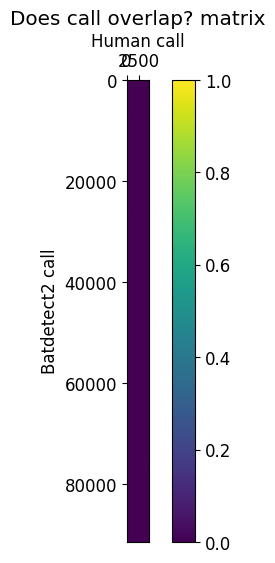

In [96]:
fig, ax = plt.subplots(1, 1, figsize=(6,6))
plt.rcParams.update({'font.size':12})

ax.set_title('Does call overlap? matrix')
im = ax.imshow(association_matrix)
ax.set_xlabel('Human call')
ax.xaxis.set_label_position('top')
ax.set_ylabel('Batdetect2 call')
ax.tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)
fig.colorbar(im, orientation='vertical')

plt.show()

In [172]:
batdetect2_subset = batdetect2_df_file[batdetect2_df_file['freq_group']=='LF'][:].copy()
human_annotations_subset = bd2_human_df_file[bd2_human_df_file['freq_group']=='LF'][:].copy()


dist_matrix = np.zeros((len(batdetect2_subset), len(human_annotations_subset)))
association_matrix = np.zeros((len(batdetect2_subset), len(human_annotations_subset)), dtype='bool')
collect_human = pd.DataFrame()
collect_bd2 = pd.DataFrame()
for index in range(len(human_annotations_subset)):
    human_row = human_annotations_subset.iloc[index]
    dist_to_all_calls = ((batdetect2_subset['peak_frequency_time_SPECTROGRAM'] - human_row['peak_frequency_time']).values)
    dist_matrix[:,index] = dist_to_all_calls
 
    dist_to_all_calls[np.abs(dist_to_all_calls)>0.001] = 1
    dist_to_all_calls[np.abs(dist_to_all_calls)<=0.001] = 0
    if np.abs(dist_to_all_calls-1).sum() > 1:
        collect_bd2 = pd.concat([collect_bd2, batdetect2_subset[dist_to_all_calls<0.5]])
        collect_human = pd.concat([collect_human, pd.DataFrame(human_row).T])

    association_matrix[:,index] = ~dist_to_all_calls.astype('bool')

human_bd2_true_positives = human_annotations_subset.loc[np.logical_or.reduce(association_matrix, axis=0)]
bd2_false_negatives = human_annotations_subset.loc[~(np.logical_or.reduce(association_matrix, axis=0))]
bd2_true_positives = batdetect2_subset.loc[np.logical_or.reduce(association_matrix, axis=1)]
bd2_false_positives = batdetect2_subset.loc[~(np.logical_or.reduce(association_matrix, axis=1))]
print(len(human_bd2_true_positives), len(bd2_false_negatives), len(bd2_true_positives), len(bd2_false_positives))

798 340 826 45725


In [173]:
save_loc_reduced_overlaps = Path(f"bd2__{threshold_tag}_chunksize{int(args['chunk_size'])}_{wav_filename}_REDUCED_OVERLAPS.csv")
filepath_reduced_overlaps = bd2_dets_save_dir / save_loc_reduced_overlaps
batdetect2_df_file_reduced_overlaps = pd.read_csv(filepath_reduced_overlaps, sep=',', index_col=0)
batdetect2_df_file_reduced_overlaps.rename(columns={'KMEANS_CLASSES':'freq_group'}, inplace=True)

In [174]:
batdetect2_subset = batdetect2_df_file_reduced_overlaps[batdetect2_df_file_reduced_overlaps['freq_group']=='LF'][:].copy()
human_annotations_subset = bd2_human_df_file[bd2_human_df_file['freq_group']=='LF'][:].copy()


dist_matrix = np.zeros((len(batdetect2_subset), len(human_annotations_subset)))
association_matrix = np.zeros((len(batdetect2_subset), len(human_annotations_subset)), dtype='bool')
collect_human = pd.DataFrame()
collect_bd2 = pd.DataFrame()
for index in range(len(batdetect2_subset)):
    batdetect2_row = batdetect2_subset.iloc[index]
    dist_to_all_calls = ((human_annotations_subset['peak_frequency_time'] - batdetect2_row['peak_frequency_time_SPECTROGRAM']).values)
    dist_matrix[index,:] = dist_to_all_calls
 
    dist_to_all_calls[np.abs(dist_to_all_calls)>0.001] = 1
    dist_to_all_calls[np.abs(dist_to_all_calls)<=0.001] = 0
    if np.abs(dist_to_all_calls-1).sum() > 1:
        collect_human = pd.concat([collect_human, human_annotations_subset[dist_to_all_calls<0.5]])
        collect_bd2 = pd.concat([collect_bd2, pd.DataFrame(batdetect2_row).T])

    association_matrix[index,:] = ~dist_to_all_calls.astype('bool')

human_bd2_true_positives = human_annotations_subset.loc[np.logical_or.reduce(association_matrix, axis=0)]
bd2_false_negatives = human_annotations_subset.loc[~(np.logical_or.reduce(association_matrix, axis=0))]
bd2_true_positives = batdetect2_subset.loc[np.logical_or.reduce(association_matrix, axis=1)]
bd2_false_positives = batdetect2_subset.loc[~(np.logical_or.reduce(association_matrix, axis=1))]
print(len(human_bd2_true_positives), len(bd2_false_negatives), len(bd2_true_positives), len(bd2_false_positives))

757 381 757 33107


In [124]:
true_positives_batdetect2_df_file_reduced_overlaps_ravenpro_df = convert_bd2df_ravenpro(true_positives_batdetect2_df_file_reduced_overlaps)
true_positives_batdetect2_df_file_reduced_overlaps_ravenpro_df.to_csv(f'20250121__20220826_070000_true_positives_dets_reduced_overlaps.txt', sep=sep, index=False)

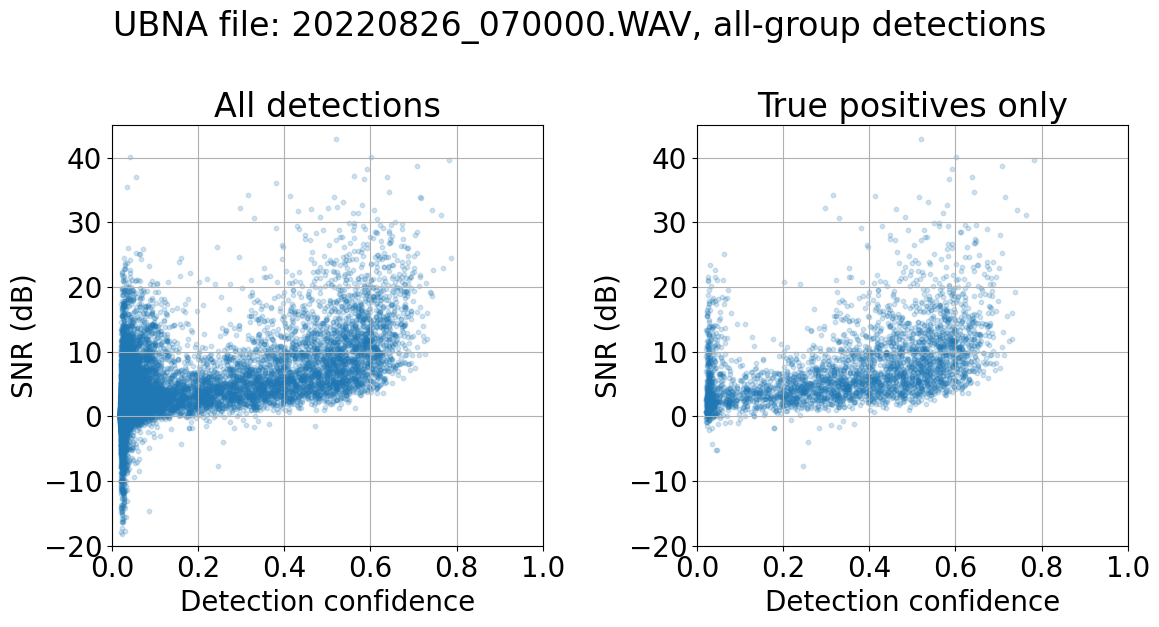

In [73]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,6.5))
plt.rcParams.update({'font.size':20})
fig.suptitle(f'UBNA file: {wav_filename}.WAV, all-group detections')

ax1.set_title(f'All detections')
ax1.scatter(batdetect2_df_file['det_prob'].values, batdetect2_df_file['SNR'].values,
            alpha=0.2, s=10)
ax1.grid(which='both')
ax1.set_xlabel('Detection confidence')
ax1.set_ylabel('SNR (dB)')
ax1.set_xlim(0, 1.0)
ax1.set_ylim(-20, 45.0)

ax2.set_title(f'True positives only')
ax2.scatter(true_positives_batdetect2_df_file['det_prob'].values, true_positives_batdetect2_df_file['SNR'].values,
            alpha=0.2, s=10)
ax2.grid(which='both')
ax2.set_xlabel('Detection confidence')
ax2.set_ylabel('SNR (dB)')
ax2.set_xlim(0, 1.0)
ax2.set_ylim(-20, 45.0)

fig.tight_layout()
plt.show()

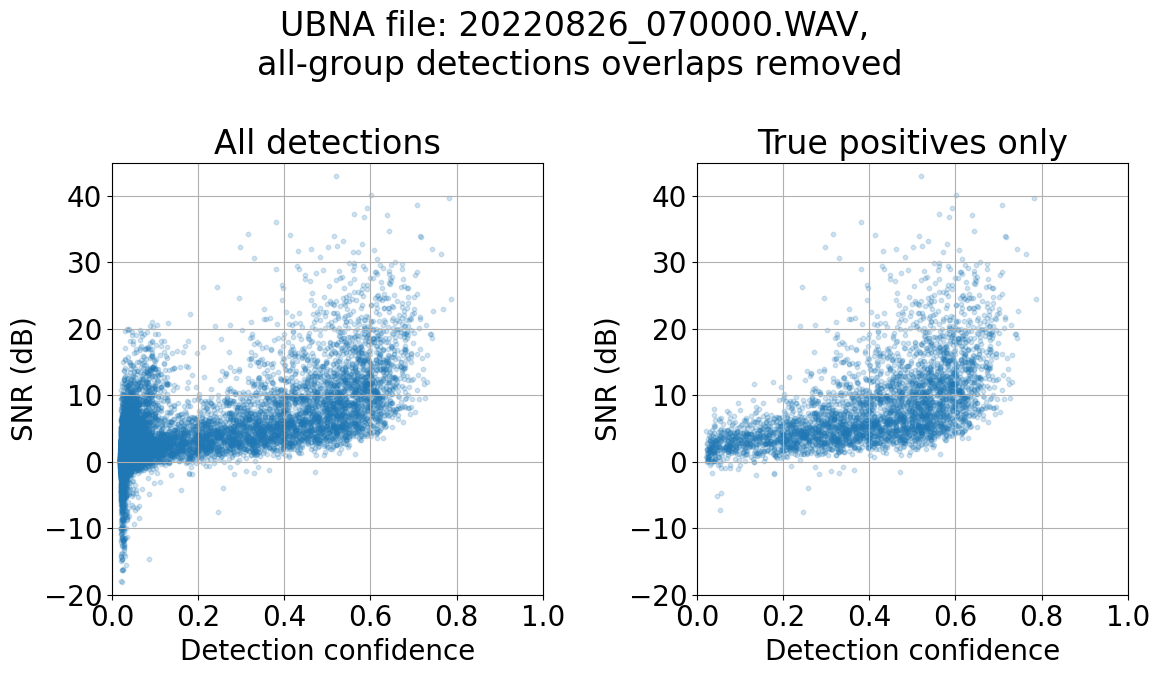

In [74]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,7))
plt.rcParams.update({'font.size':20})
fig.suptitle(f'UBNA file: {wav_filename}.WAV, \nall-group detections overlaps removed')

ax1.set_title(f'All detections')
ax1.scatter(batdetect2_df_file_reduced_overlaps['det_prob'].values, 
            batdetect2_df_file_reduced_overlaps['SNR'].values,
            alpha=0.2, s=10)
ax1.grid(which='both')
ax1.set_xlabel('Detection confidence')
ax1.set_ylabel('SNR (dB)')
ax1.set_xlim(0, 1.0)
ax1.set_ylim(-20, 45.0)

ax2.set_title(f'True positives only')
ax2.scatter(true_positives_batdetect2_df_file_reduced_overlaps['det_prob'].values, 
            true_positives_batdetect2_df_file_reduced_overlaps['SNR'].values,
            alpha=0.2, s=10)
ax2.grid(which='both')
ax2.set_xlabel('Detection confidence')
ax2.set_ylabel('SNR (dB)')
ax2.set_xlim(0, 1.0)
ax2.set_ylim(-20, 45.0)

fig.tight_layout()
plt.show()

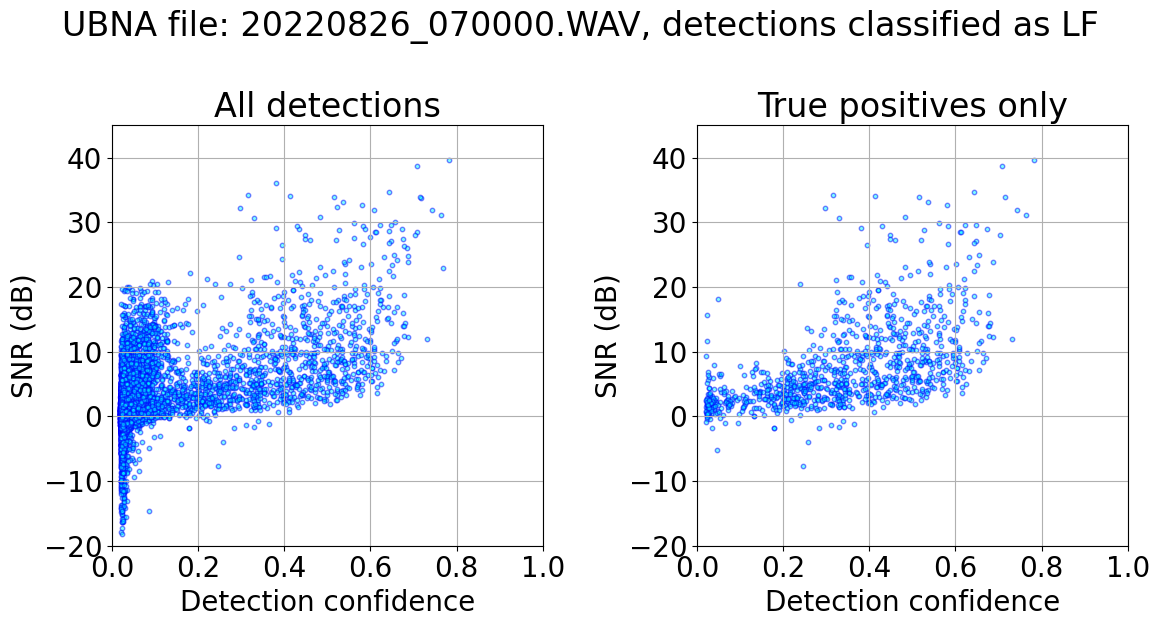

In [70]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,6.5))
plt.rcParams.update({'font.size':20})
fig.suptitle(f'UBNA file: {wav_filename}.WAV, detections classified as LF')
ax1.set_title(f'All detections')
lf_file_batdetct2_df = batdetect2_df_file[batdetect2_df_file['freq_group']=='LF']
ax1.scatter(lf_file_batdetct2_df['det_prob'].values, lf_file_batdetct2_df['SNR'].values,
            alpha=0.5, s=10, facecolor='cyan', edgecolor='blue')
ax1.grid(which='both')
ax1.set_xlabel('Detection confidence')
ax1.set_ylabel('SNR (dB)')
ax1.set_xlim(0, 1.0)
ax1.set_ylim(-20, 45.0)

ax2.set_title(f'True positives only')
lf_file_batdetct2_df_true_positives = true_positives_batdetect2_df_file[true_positives_batdetect2_df_file['freq_group']=='LF']
ax2.scatter(lf_file_batdetct2_df_true_positives['det_prob'].values, lf_file_batdetct2_df_true_positives['SNR'].values,
            alpha=0.5, s=10, facecolor='cyan', edgecolor='blue')
ax2.grid(which='both')
ax2.set_xlabel('Detection confidence')
ax2.set_ylabel('SNR (dB)')
ax2.set_xlim(0, 1.0)
ax2.set_ylim(-20, 45.0)

fig.tight_layout()
plt.show()

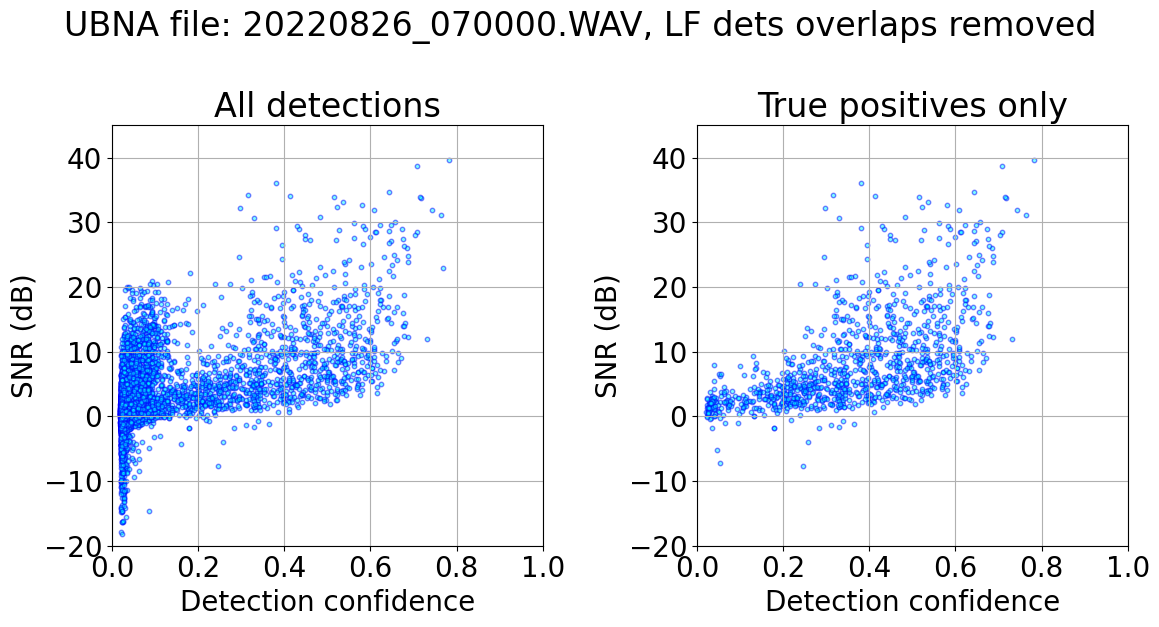

In [75]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,6.5))
plt.rcParams.update({'font.size':20})
fig.suptitle(f'UBNA file: {wav_filename}.WAV, LF dets overlaps removed')
ax1.set_title(f'All detections')
lf_file_batdetct2_df_reduced_overlaps = batdetect2_df_file_reduced_overlaps[batdetect2_df_file_reduced_overlaps['freq_group']=='LF']
ax1.scatter(lf_file_batdetct2_df_reduced_overlaps['det_prob'].values, 
            lf_file_batdetct2_df_reduced_overlaps['SNR'].values,
            alpha=0.5, s=10, facecolor='cyan', edgecolor='blue')
ax1.grid(which='both')
ax1.set_xlabel('Detection confidence')
ax1.set_ylabel('SNR (dB)')
ax1.set_xlim(0, 1.0)
ax1.set_ylim(-20, 45.0)

ax2.set_title(f'True positives only')
lf_file_batdetct2_df_true_positives_reduced_pverlaps = true_positives_batdetect2_df_file_reduced_overlaps[true_positives_batdetect2_df_file_reduced_overlaps['freq_group']=='LF']
ax2.scatter(lf_file_batdetct2_df_true_positives_reduced_pverlaps['det_prob'].values, 
            lf_file_batdetct2_df_true_positives_reduced_pverlaps['SNR'].values,
            alpha=0.5, s=10, facecolor='cyan', edgecolor='blue')
ax2.grid(which='both')
ax2.set_xlabel('Detection confidence')
ax2.set_ylabel('SNR (dB)')
ax2.set_xlim(0, 1.0)
ax2.set_ylim(-20, 45.0)

fig.tight_layout()
plt.show()

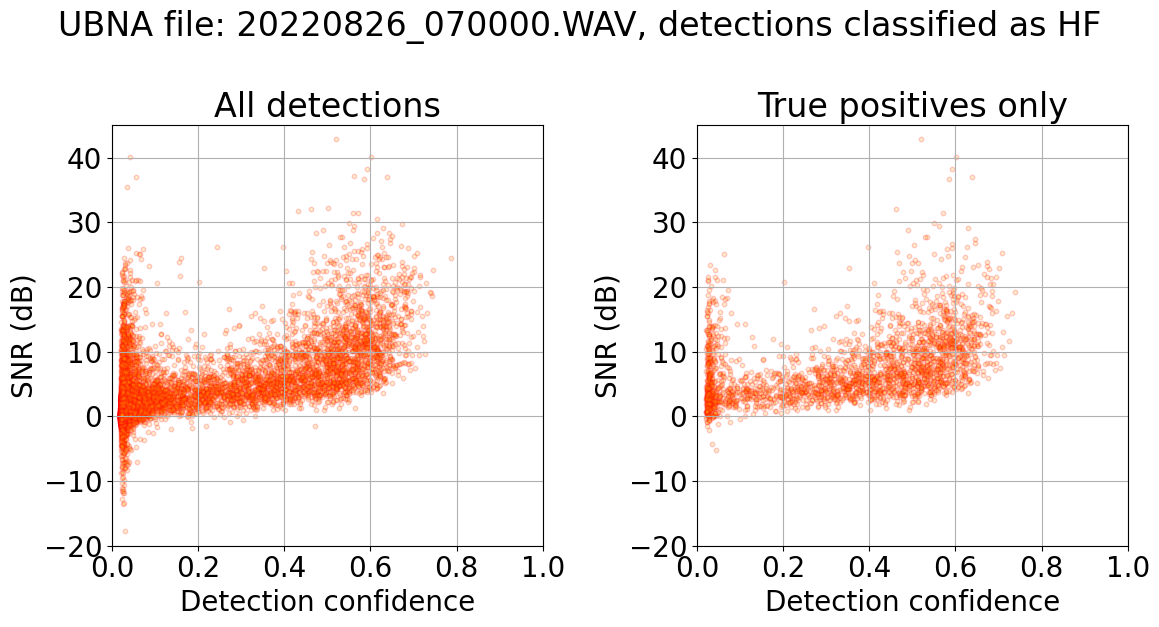

In [78]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,6.5))
plt.rcParams.update({'font.size':20})
fig.suptitle(f'UBNA file: {wav_filename}.WAV, detections classified as HF')
ax1.set_title(f'All detections')
hf_file_batdetct2_df = batdetect2_df_file[batdetect2_df_file['freq_group']=='HF']
ax1.scatter(hf_file_batdetct2_df['det_prob'].values, hf_file_batdetct2_df['SNR'].values,
            alpha=0.2, s=10, facecolor='orange', edgecolor='red')
ax1.grid(which='both')
ax1.set_xlabel('Detection confidence')
ax1.set_ylabel('SNR (dB)')
ax1.set_xlim(0, 1.0)
ax1.set_ylim(-20, 45.0)

ax2.set_title(f'True positives only')
hf_file_batdetct2_df_true_positives = true_positives_batdetect2_df_file[true_positives_batdetect2_df_file['freq_group']=='HF']
ax2.scatter(hf_file_batdetct2_df_true_positives['det_prob'].values, hf_file_batdetct2_df_true_positives['SNR'].values,
            alpha=0.2, s=10, facecolor='orange', edgecolor='red')
ax2.grid(which='both')
ax2.set_xlabel('Detection confidence')
ax2.set_ylabel('SNR (dB)')
ax2.set_xlim(0, 1.0)
ax2.set_ylim(-20, 45.0)

fig.tight_layout()
plt.show()

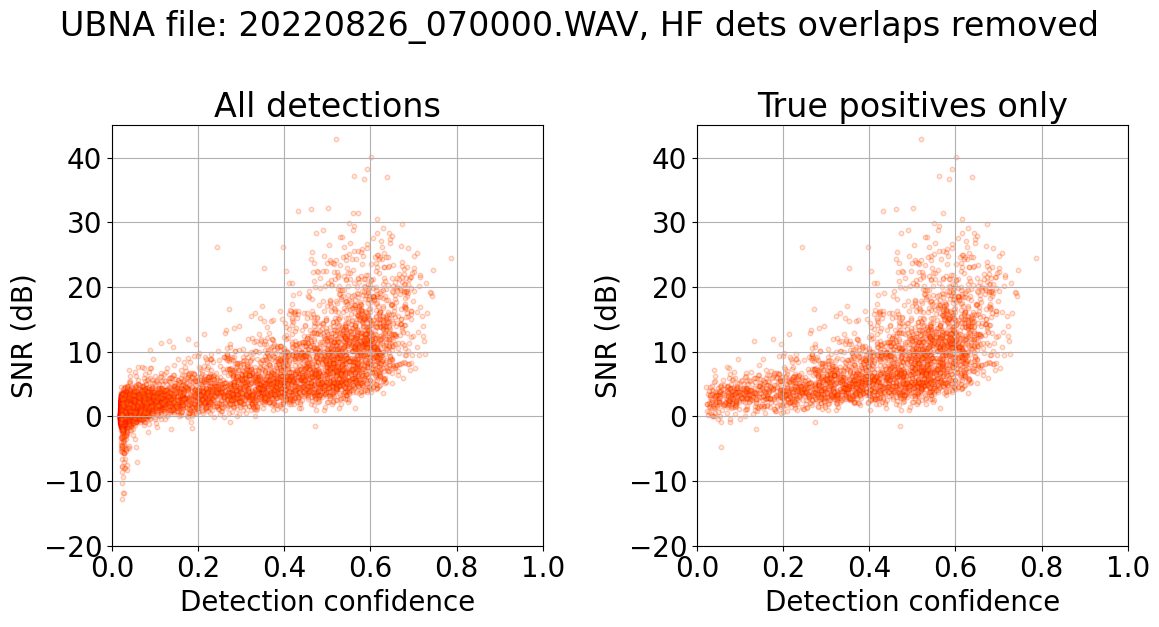

In [77]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,6.5))
plt.rcParams.update({'font.size':20})
fig.suptitle(f'UBNA file: {wav_filename}.WAV, HF dets overlaps removed')
ax1.set_title(f'All detections')
hf_file_batdetct2_df_reduced_overlaps = batdetect2_df_file_reduced_overlaps[batdetect2_df_file_reduced_overlaps['freq_group']=='HF']
ax1.scatter(hf_file_batdetct2_df_reduced_overlaps['det_prob'].values, 
            hf_file_batdetct2_df_reduced_overlaps['SNR'].values,
            alpha=0.2, s=10, facecolor='orange', edgecolor='red')
ax1.grid(which='both')
ax1.set_xlabel('Detection confidence')
ax1.set_ylabel('SNR (dB)')
ax1.set_xlim(0, 1.0)
ax1.set_ylim(-20, 45.0)

ax2.set_title(f'True positives only')
hf_file_batdetct2_df_true_positives_reduced_overlaps = true_positives_batdetect2_df_file_reduced_overlaps[true_positives_batdetect2_df_file_reduced_overlaps['freq_group']=='HF']
ax2.scatter(hf_file_batdetct2_df_true_positives_reduced_overlaps['det_prob'].values, 
            hf_file_batdetct2_df_true_positives_reduced_overlaps['SNR'].values,
            alpha=0.2, s=10, facecolor='orange', edgecolor='red')
ax2.grid(which='both')
ax2.set_xlabel('Detection confidence')
ax2.set_ylabel('SNR (dB)')
ax2.set_xlim(0, 1.0)
ax2.set_ylim(-20, 45.0)

fig.tight_layout()
plt.show()

In [89]:
hf_file_batdetct2_df_true_positives

,freq_group,peak_frequency_time_SPECTROGRAM,peak_frequency_SPECTROGRAM,peak_frequency_WELCH,SNR,start_time,end_time,low_freq,high_freq,class,class_prob,det_prob,individual,event,sampling_rate,input_file
0,HF,1.7329,47250.0,47040.0,3.570422,1.7295,1.7371,46953,51351,Pipistrellus pipistrellus,0.388,0.428,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...
1,HF,3.773733,46500.0,46080.0,6.879404,3.7705,3.7771,45234,54096,Pipistrellus pipistrellus,0.466,0.512,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...
2,HF,4.166333,48000.0,48000.0,3.463646,4.1625,4.1685,45234,59329,Pipistrellus pipistrellus,0.218,0.312,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...
3,HF,4.444933,52500.0,51840.0,8.89113,4.4415,4.4479,52109,59097,Pipistrellus pipistrellus,0.02,0.037,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...
4,HF,4.576767,48750.0,48960.0,12.421702,4.5735,4.5789,44375,59685,Pipistrellus pipistrellus,0.324,0.446,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3396,HF,1787.263733,40500.0,39360.0,4.490047,1787.2595,1787.2686,38359,45558,Pipistrellus nathusii,0.555,0.597,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...
3397,HF,1787.481833,45000.0,44160.0,1.970963,1787.4815,1787.491,38359,44446,Pipistrellus nathusii,0.441,0.462,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...
3398,HF,1787.9641,40500.0,40320.0,6.562988,1787.9595,1787.9694,37500,45913,Pipistrellus nathusii,0.537,0.591,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...
3400,HF,1788.419,41250.0,41280.0,5.583953,1788.4135,1788.4225,40078,49982,Pipistrellus nathusii,0.441,0.566,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...


In [82]:
hf_file_batdetct2_df_true_positives_reduced_overlaps

,freq_group,peak_frequency_time_SPECTROGRAM,peak_frequency_SPECTROGRAM,peak_frequency_WELCH,SNR,start_time,end_time,low_freq,high_freq,class,class_prob,det_prob,individual,event,sampling_rate,input_file
0,HF,1.7329,47250.0,47040.0,3.570422,1.7295,1.7371,46953,51351,Pipistrellus pipistrellus,0.388,0.428,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...
1,HF,3.773733,46500.0,46080.0,6.879404,3.7705,3.7771,45234,54096,Pipistrellus pipistrellus,0.466,0.512,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...
2,HF,3.914267,47250.0,46080.0,8.649871,3.9105,3.9154,45234,59565,Pipistrellus pipistrellus,0.266,0.355,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...
3,HF,4.0455,52500.0,48000.0,2.673958,4.0445,4.051,46953,53999,Pipistrellus pipistrellus,0.046,0.048,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...
4,HF,4.166333,48000.0,48000.0,3.463646,4.1625,4.1685,45234,59329,Pipistrellus pipistrellus,0.218,0.312,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3974,HF,1787.779767,39750.0,39360.0,9.656562,1787.7745,1787.7849,37500,46675,Pipistrellus nathusii,0.492,0.587,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...
3975,HF,1787.9641,40500.0,40320.0,6.562988,1787.9595,1787.9694,37500,45913,Pipistrellus nathusii,0.537,0.591,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...
3976,HF,1788.217133,40500.0,41280.0,8.990165,1788.2125,1788.2212,39218,48186,Pipistrellus nathusii,0.431,0.544,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...
3977,HF,1788.419,41250.0,41280.0,5.583953,1788.4135,1788.4225,40078,49982,Pipistrellus nathusii,0.441,0.566,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...


In [90]:
pd.merge(hf_file_batdetct2_df_true_positives, hf_file_batdetct2_df_true_positives_reduced_overlaps, how='inner')

,freq_group,peak_frequency_time_SPECTROGRAM,peak_frequency_SPECTROGRAM,peak_frequency_WELCH,SNR,start_time,end_time,low_freq,high_freq,class,class_prob,det_prob,individual,event,sampling_rate,input_file
0,HF,1.7329,47250.0,47040.0,3.570422,1.7295,1.7371,46953,51351,Pipistrellus pipistrellus,0.388,0.428,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...
1,HF,3.773733,46500.0,46080.0,6.879404,3.7705,3.7771,45234,54096,Pipistrellus pipistrellus,0.466,0.512,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...
2,HF,4.166333,48000.0,48000.0,3.463646,4.1625,4.1685,45234,59329,Pipistrellus pipistrellus,0.218,0.312,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...
3,HF,4.576767,48750.0,48960.0,12.421702,4.5735,4.5789,44375,59685,Pipistrellus pipistrellus,0.324,0.446,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...
4,HF,4.710767,51750.0,51840.0,12.128914,4.7075,4.7129,45234,65641,Pipistrellus pipistrellus,0.284,0.408,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1985,HF,1787.263733,40500.0,39360.0,4.490047,1787.2595,1787.2686,38359,45558,Pipistrellus nathusii,0.555,0.597,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...
1986,HF,1787.481833,45000.0,44160.0,1.970963,1787.4815,1787.491,38359,44446,Pipistrellus nathusii,0.441,0.462,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...
1987,HF,1787.9641,40500.0,40320.0,6.562988,1787.9595,1787.9694,37500,45913,Pipistrellus nathusii,0.537,0.591,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...
1988,HF,1788.419,41250.0,41280.0,5.583953,1788.4135,1788.4225,40078,49982,Pipistrellus nathusii,0.441,0.566,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...


In [117]:
merged_df = pd.merge(hf_file_batdetct2_df, hf_file_batdetct2_df_true_positives, 
                     on=list(hf_file_batdetct2_df_true_positives.columns), how='outer', indicator=True)
merged_df.head(10)

,freq_group,peak_frequency_time_SPECTROGRAM,peak_frequency_SPECTROGRAM,peak_frequency_WELCH,SNR,start_time,end_time,low_freq,high_freq,class,class_prob,det_prob,individual,event,sampling_rate,input_file,_merge
0,HF,0.008833,79500.0,70080.0,-0.84435,0.0015,0.0328,68437,79536,Rhinolophus ferrumequinum,0.028,0.028,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...,left_only
1,HF,0.001833,50250.0,48960.0,1.866691,0.0015,0.0099,47812,51961,Pipistrellus pipistrellus,0.029,0.035,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...,left_only
2,HF,0.0739,21000.0,20160.0,5.142153,0.0725,0.0786,11718,63812,Myotis bechsteinii,0.009,0.025,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...,left_only
3,HF,0.103,78000.0,72960.0,0.030461,0.0805,0.1215,68437,83068,Rhinolophus ferrumequinum,0.027,0.027,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...,left_only
4,HF,0.250467,74250.0,72000.0,0.301496,0.2355,0.2747,68437,81583,Rhinolophus ferrumequinum,0.025,0.025,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...,left_only
5,HF,0.290133,70500.0,70080.0,-0.696341,0.2875,0.3262,68437,82718,Rhinolophus ferrumequinum,0.023,0.023,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...,left_only
6,HF,0.3735,78750.0,70080.0,0.211191,0.3455,0.388,68437,82775,Rhinolophus ferrumequinum,0.023,0.023,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...,left_only
7,HF,0.539133,80250.0,73920.0,0.127776,0.5385,0.5792,68437,83037,Rhinolophus ferrumequinum,0.023,0.023,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...,left_only
8,HF,0.582433,78000.0,72000.0,0.058135,0.5585,0.5934,68437,81505,Rhinolophus ferrumequinum,0.024,0.024,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...,left_only
9,HF,0.707567,81000.0,80640.0,0.022428,0.6755,0.7151,68437,82477,Rhinolophus ferrumequinum,0.027,0.027,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...,left_only


In [118]:
uncommon_left_rows = merged_df[merged_df['_merge'] == 'left_only'].reset_index(drop=True)
uncommon_right_rows = merged_df[merged_df['_merge'] == 'right_only'].reset_index(drop=True)
uncommon_left_rows.head(10)

,freq_group,peak_frequency_time_SPECTROGRAM,peak_frequency_SPECTROGRAM,peak_frequency_WELCH,SNR,start_time,end_time,low_freq,high_freq,class,class_prob,det_prob,individual,event,sampling_rate,input_file,_merge
0,HF,0.008833,79500.0,70080.0,-0.84435,0.0015,0.0328,68437,79536,Rhinolophus ferrumequinum,0.028,0.028,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...,left_only
1,HF,0.001833,50250.0,48960.0,1.866691,0.0015,0.0099,47812,51961,Pipistrellus pipistrellus,0.029,0.035,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...,left_only
2,HF,0.0739,21000.0,20160.0,5.142153,0.0725,0.0786,11718,63812,Myotis bechsteinii,0.009,0.025,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...,left_only
3,HF,0.103,78000.0,72960.0,0.030461,0.0805,0.1215,68437,83068,Rhinolophus ferrumequinum,0.027,0.027,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...,left_only
4,HF,0.250467,74250.0,72000.0,0.301496,0.2355,0.2747,68437,81583,Rhinolophus ferrumequinum,0.025,0.025,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...,left_only
5,HF,0.290133,70500.0,70080.0,-0.696341,0.2875,0.3262,68437,82718,Rhinolophus ferrumequinum,0.023,0.023,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...,left_only
6,HF,0.3735,78750.0,70080.0,0.211191,0.3455,0.388,68437,82775,Rhinolophus ferrumequinum,0.023,0.023,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...,left_only
7,HF,0.539133,80250.0,73920.0,0.127776,0.5385,0.5792,68437,83037,Rhinolophus ferrumequinum,0.023,0.023,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...,left_only
8,HF,0.582433,78000.0,72000.0,0.058135,0.5585,0.5934,68437,81505,Rhinolophus ferrumequinum,0.024,0.024,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...,left_only
9,HF,0.707567,81000.0,80640.0,0.022428,0.6755,0.7151,68437,82477,Rhinolophus ferrumequinum,0.027,0.027,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...,left_only


In [119]:
uncommon_left_ravenpro_df = convert_bd2df_ravenpro(uncommon_left_rows)
uncommon_left_ravenpro_df.to_csv(f'20250120__20220826_070000_HF_dets.txt', sep=sep, index=False)

In [120]:
uncommon_right_rows.head(10)

,freq_group,peak_frequency_time_SPECTROGRAM,peak_frequency_SPECTROGRAM,peak_frequency_WELCH,SNR,start_time,end_time,low_freq,high_freq,class,class_prob,det_prob,individual,event,sampling_rate,input_file,_merge


In [111]:
uncommon_right_ravenpro_df = convert_bd2df_ravenpro(uncommon_right_rows)
uncommon_right_ravenpro_df.to_csv(f'20250120__20220826_070000_HF_dets_reduced_overlaps.txt', sep=sep, index=False)

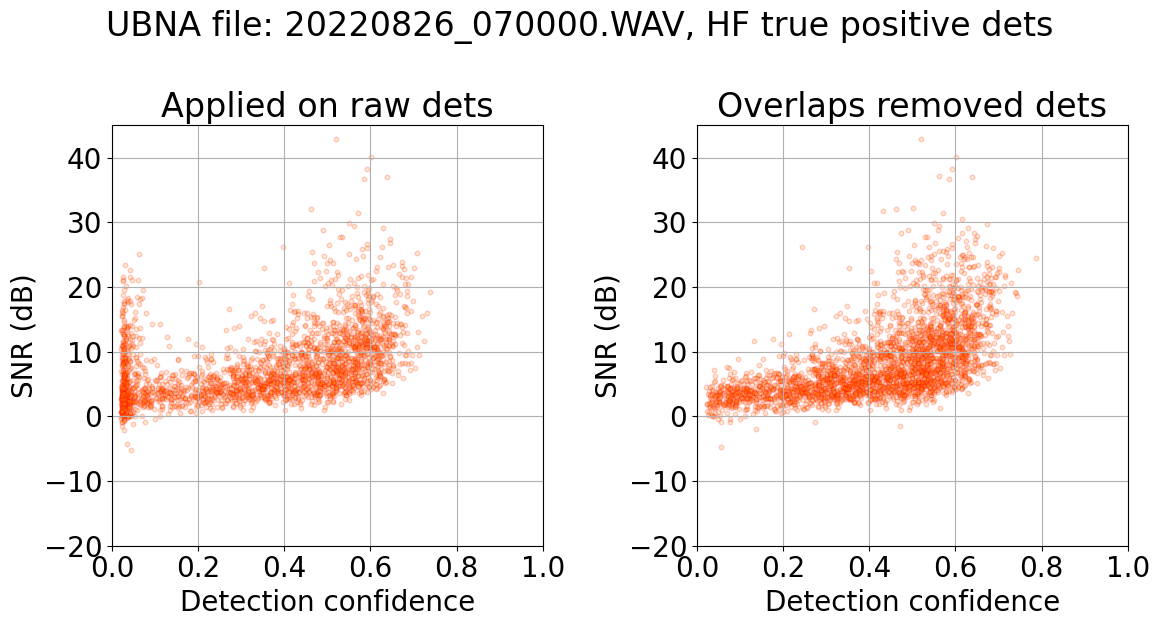

In [115]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,6.5))
plt.rcParams.update({'font.size':20})
fig.suptitle(f'UBNA file: {wav_filename}.WAV, HF true positive dets')
ax1.set_title(f'Applied on raw dets')
ax1.scatter(hf_file_batdetct2_df_true_positives['det_prob'].values, 
            hf_file_batdetct2_df_true_positives['SNR'].values,
            alpha=0.2, s=10, facecolor='orange', edgecolor='red')
ax1.grid(which='both')
ax1.set_xlabel('Detection confidence')
ax1.set_ylabel('SNR (dB)')
ax1.set_xlim(0, 1.0)
ax1.set_ylim(-20, 45.0)

ax2.set_title(f'Overlaps removed dets')
ax2.scatter(hf_file_batdetct2_df_true_positives_reduced_overlaps['det_prob'].values, 
            hf_file_batdetct2_df_true_positives_reduced_overlaps['SNR'].values,
            alpha=0.2, s=10, facecolor='orange', edgecolor='red')
ax2.grid(which='both')
ax2.set_xlabel('Detection confidence')
ax2.set_ylabel('SNR (dB)')
ax2.set_xlim(0, 1.0)
ax2.set_ylim(-20, 45.0)

fig.tight_layout()
plt.show()

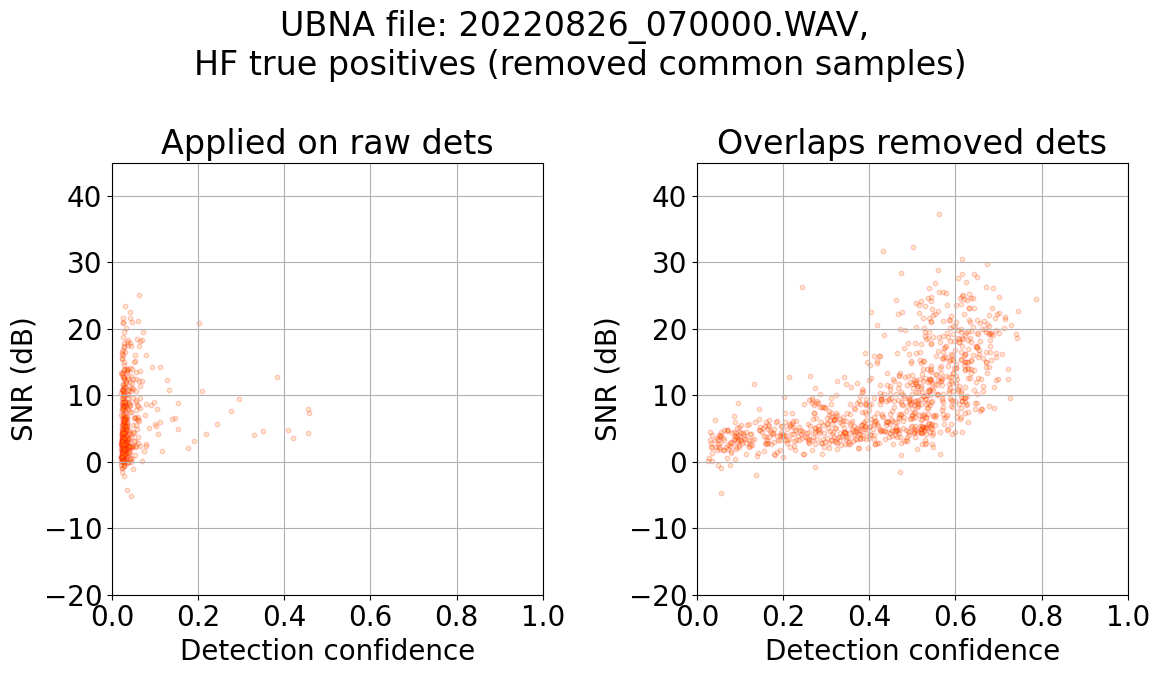

In [116]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,7))
plt.rcParams.update({'font.size':20})
fig.suptitle(f'UBNA file: {wav_filename}.WAV, \nHF true positives (removed common samples)')
ax1.set_title(f'Applied on raw dets')
ax1.scatter(uncommon_left_rows['det_prob'].values, 
            uncommon_left_rows['SNR'].values,
            alpha=0.2, s=10, facecolor='orange', edgecolor='red')
ax1.grid(which='both')
ax1.set_xlabel('Detection confidence')
ax1.set_ylabel('SNR (dB)')
ax1.set_xlim(0, 1.0)
ax1.set_ylim(-20, 45.0)

ax2.set_title(f'Overlaps removed dets')
ax2.scatter(uncommon_right_rows['det_prob'].values, 
            uncommon_right_rows['SNR'].values,
            alpha=0.2, s=10, facecolor='orange', edgecolor='red')
ax2.grid(which='both')
ax2.set_xlabel('Detection confidence')
ax2.set_ylabel('SNR (dB)')
ax2.set_xlim(0, 1.0)
ax2.set_ylim(-20, 45.0)

fig.tight_layout()
plt.show()

In [40]:
all_files_batdetct2_df_reduced_overlaps = pd.DataFrame()
all_files_batdetct2_df_true_positives_reduced_overlaps = pd.DataFrame()
for file_num, file_key in enumerate(file_keys):
    wav_filename = file_key
    site = file_sites[file_key]
    plot_file = Path(f'{raventxt_human_files_dir}/{wav_filename}.WAV')
    raventxt_human_filename = f'{wav_filename}_manually_verified_by_AK_with_groups'

    snr_included_ravenpro_human_txt = pd.read_csv(f'{raventxt_human_files_dir}/{raventxt_human_filename}_ravenpro_SNR_aditya_SNR_and_peakfreqtime.txt', sep=sep)
    bd2_human_df_file = snr_included_ravenpro_human_txt.copy()
    bd2_human_df_file = bd2_human_df_file.drop(columns=['Selection', 'View', 'Channel'])
    bd2_human_df_file.rename(columns={'Begin Time (s)':'start_time',
                                'End Time (s)':'end_time',
                                'Low Freq (Hz)':'low_freq',
                                'High Freq (Hz)':'high_freq',
                                'Delta Time (s)':'delta_time_s',
                                'Manually-Verified Phonic Group':'freq_group',
                                'SNR NIST Quick (dB)':'snr_nist_quick_dB'}, inplace=True)
    bd2_human_df_file.sort_values('start_time', inplace=True)
    bd2_human_df_file = bd2_human_df_file.reset_index(drop=True)

    args = dict()
    args['chunk_size'] = 2
    args['detection_threshold'] = 0.00
    ones = int(args['detection_threshold'])
    decimals = int(int(100*(args['detection_threshold'])) % 100)
    threshold_tag = f"threshold{ones}p{decimals:02}"
    save_loc_reduced_overlaps = Path(f"bd2__{threshold_tag}_chunksize{int(args['chunk_size'])}_{wav_filename}_REDUCED_OVERLAPS.csv")
    filepath_reduced_overlaps = bd2_dets_save_dir / save_loc_reduced_overlaps
    batdetect2_df_file_reduced_overlaps = pd.read_csv(filepath_reduced_overlaps, sep=',', index_col=0)
    batdetect2_df_file_reduced_overlaps.rename(columns={'KMEANS_CLASSES':'freq_group'}, inplace=True)
    all_files_batdetct2_df_reduced_overlaps = pd.concat([all_files_batdetct2_df_reduced_overlaps, batdetect2_df_file_reduced_overlaps])

    true_positives_batdetect2_df_file_reduced_overlaps, true_positives = return_true_positives_using_human_df(bd2_human_df_file, 
                                                                                                              batdetect2_df_file_reduced_overlaps, debug=False)
    all_files_batdetct2_df_true_positives_reduced_overlaps = pd.concat([all_files_batdetct2_df_true_positives_reduced_overlaps, 
                                                                        true_positives_batdetect2_df_file_reduced_overlaps])

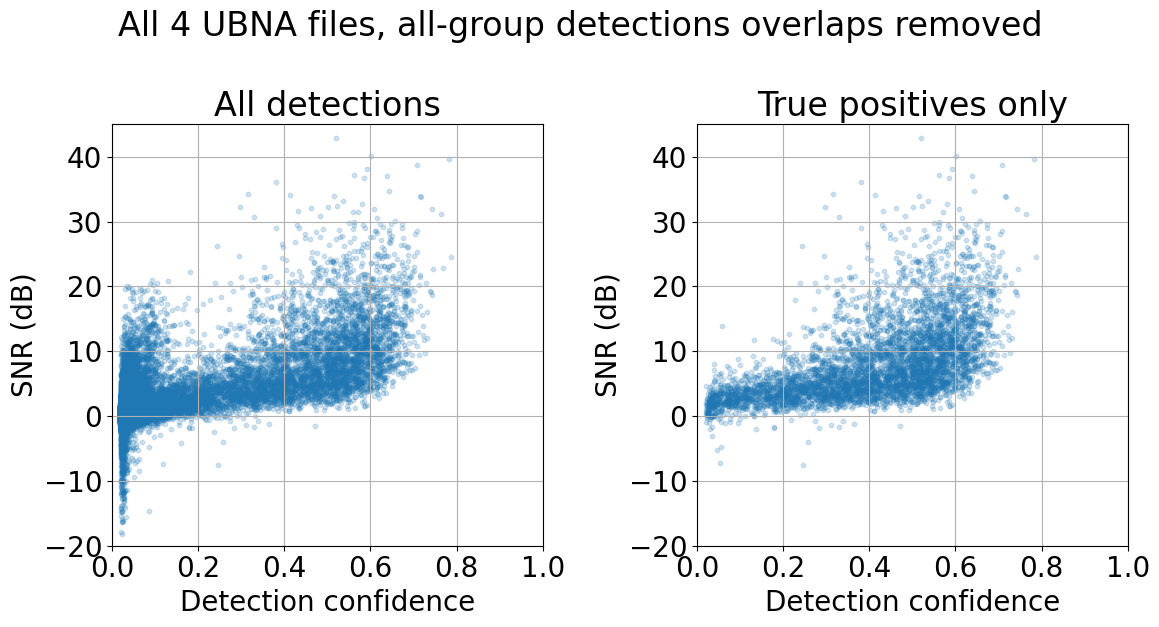

In [43]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,6.5))
plt.rcParams.update({'font.size':20})
fig.suptitle(f'All 4 UBNA files, all-group detections overlaps removed')

ax1.set_title(f'All detections')
ax1.scatter(all_files_batdetct2_df_reduced_overlaps['det_prob'].values, 
            all_files_batdetct2_df_reduced_overlaps['SNR'].values, alpha=0.2, s=10)
ax1.grid(which='both')
ax1.set_xlabel('Detection confidence')
ax1.set_ylabel('SNR (dB)')
ax1.set_xlim(0, 1.0)
ax1.set_ylim(-20, 45)

ax2.set_title(f'True positives only')
ax2.scatter(all_files_batdetct2_df_true_positives_reduced_overlaps['det_prob'].values, 
            all_files_batdetct2_df_true_positives_reduced_overlaps['SNR'].values, alpha=0.2, s=10)
ax2.grid(which='both')
ax2.set_xlabel('Detection confidence')
ax2.set_ylabel('SNR (dB)')
ax2.set_xlim(0, 1.0)
ax2.set_ylim(-20, 45)

fig.tight_layout()
plt.show()

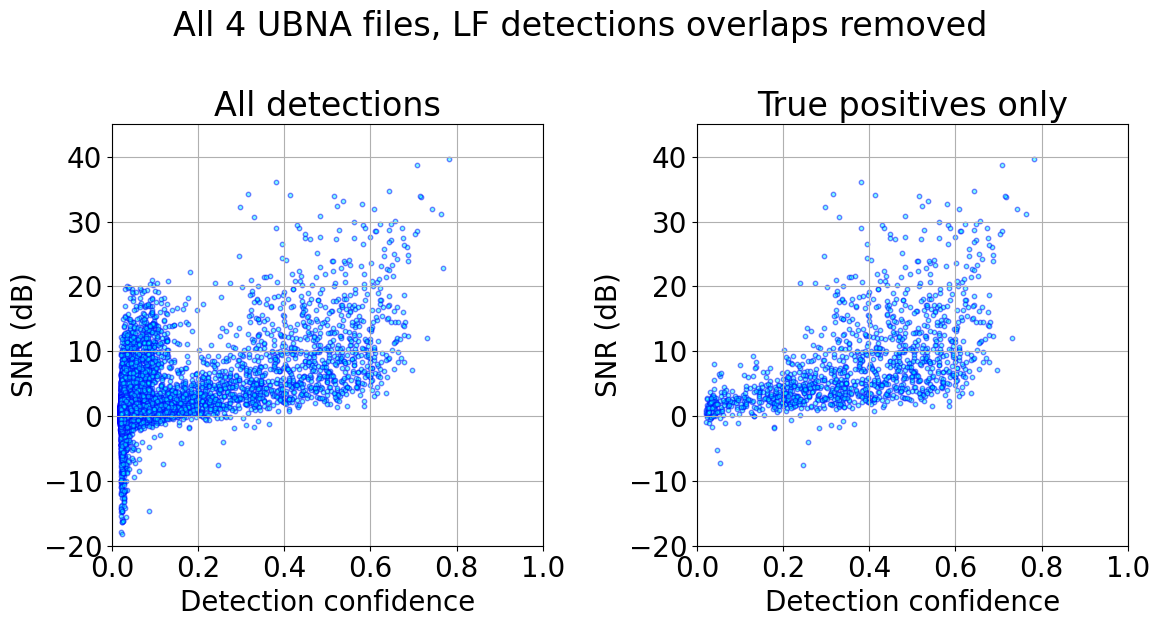

In [46]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,6.5))
plt.rcParams.update({'font.size':20})
fig.suptitle(f'All 4 UBNA files, LF detections overlaps removed')

ax1.set_title(f'All detections')
lf_all_files_batdetct2_df_reduced_overlaps = all_files_batdetct2_df_reduced_overlaps[all_files_batdetct2_df_reduced_overlaps['freq_group']=='LF']
ax1.scatter(lf_all_files_batdetct2_df_reduced_overlaps['det_prob'].values, 
            lf_all_files_batdetct2_df_reduced_overlaps['SNR'].values,
            alpha=0.5, s=10, facecolor='cyan', edgecolor='blue')
ax1.grid(which='both')
ax1.set_xlabel('Detection confidence')
ax1.set_ylabel('SNR (dB)')
ax1.set_xlim(0, 1.0)
ax1.set_ylim(-20, 45)

ax2.set_title(f'True positives only')
lf_all_files_batdetct2_df_true_positives_reduced_overlaps = all_files_batdetct2_df_true_positives_reduced_overlaps[all_files_batdetct2_df_true_positives_reduced_overlaps['freq_group']=='LF']
ax2.scatter(lf_all_files_batdetct2_df_true_positives_reduced_overlaps['det_prob'].values, 
            lf_all_files_batdetct2_df_true_positives_reduced_overlaps['SNR'].values,
            alpha=0.5, s=10, facecolor='cyan', edgecolor='blue')
ax2.grid(which='both')
ax2.set_xlabel('Detection confidence')
ax2.set_ylabel('SNR (dB)')
ax2.set_xlim(0, 1.0)
ax2.set_ylim(-20, 45)

fig.tight_layout()
plt.show()

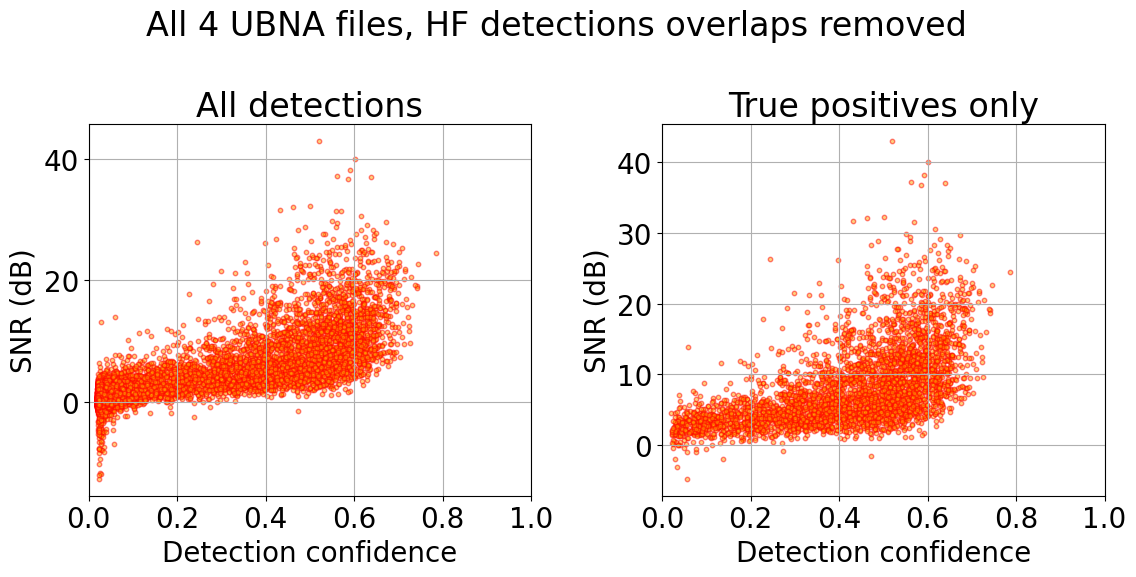

In [48]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,6))
plt.rcParams.update({'font.size':20})
fig.suptitle(f'All 4 UBNA files, HF detections overlaps removed')

ax1.set_title(f'All detections')
hf_all_files_batdetct2_df_reduced_overlaps = all_files_batdetct2_df_reduced_overlaps[all_files_batdetct2_df_reduced_overlaps['freq_group']=='HF']
ax1.scatter(hf_all_files_batdetct2_df_reduced_overlaps['det_prob'].values, 
            hf_all_files_batdetct2_df_reduced_overlaps['SNR'].values,
            alpha=0.5, s=10, facecolor='orange', edgecolor='red')
ax1.grid(which='both')
ax1.set_xlabel('Detection confidence')
ax1.set_ylabel('SNR (dB)')
ax1.set_xlim(0, 1.0)

ax2.set_title(f'True positives only')
hf_all_files_batdetct2_df_true_positives_reduced_overlaps = all_files_batdetct2_df_true_positives_reduced_overlaps[all_files_batdetct2_df_true_positives_reduced_overlaps['freq_group']=='HF']
ax2.scatter(hf_all_files_batdetct2_df_true_positives_reduced_overlaps['det_prob'].values, 
            hf_all_files_batdetct2_df_true_positives_reduced_overlaps['SNR'].values,
            alpha=0.5, s=10, facecolor='orange', edgecolor='red')
ax2.grid(which='both')
ax2.set_xlabel('Detection confidence')
ax2.set_ylabel('SNR (dB)')
ax2.set_xlim(0, 1.0)

fig.tight_layout()
plt.show()

In [49]:
batdetect2_eval = pd.DataFrame()
batdetect2_eval_LF = pd.DataFrame()
batdetect2_eval_HF = pd.DataFrame()
for file_key in file_keys:
    wav_filename = file_key
    site = file_sites[file_key]
    plot_file = Path(f'{raventxt_human_files_dir}/{wav_filename}.WAV')
    raventxt_human_filename = f'{wav_filename}_manually_verified_by_AK_with_groups'

    snr_included_ravenpro_human_txt = pd.read_csv(f'{raventxt_human_files_dir}/{raventxt_human_filename}_ravenpro_SNR_aditya_SNR_and_peakfreqtime.txt', sep=sep)
    bd2_human_df_file = snr_included_ravenpro_human_txt.copy()
    bd2_human_df_file = bd2_human_df_file.drop(columns=['Selection', 'View', 'Channel'])
    bd2_human_df_file.rename(columns={'Begin Time (s)':'start_time',
                                'End Time (s)':'end_time',
                                'Low Freq (Hz)':'low_freq',
                                'High Freq (Hz)':'high_freq',
                                'Delta Time (s)':'delta_time_s',
                                'Manually-Verified Phonic Group':'freq_group',
                                'SNR NIST Quick (dB)':'snr_nist_quick_dB'}, inplace=True)
    bd2_human_df_file.sort_values('start_time', inplace=True)

    args = dict()
    args['chunk_size'] = 2
    args['detection_threshold'] = 0.00
    ones = int(args['detection_threshold'])
    decimals = int(int(100*(args['detection_threshold'])) % 100)
    threshold_tag = f"threshold{ones}p{decimals:02}"
    save_loc_reduced_overlaps = Path(f"bd2__{threshold_tag}_chunksize{int(args['chunk_size'])}_{wav_filename}_REDUCED_OVERLAPS.csv")
    filepath_reduced_overlaps = bd2_dets_save_dir / save_loc_reduced_overlaps
    batdetect2_df_file_reduced_overlaps = pd.read_csv(filepath_reduced_overlaps, sep=',', index_col=0)
    batdetect2_df_file_reduced_overlaps.rename(columns={'KMEANS_CLASSES':'freq_group'}, inplace=True)

    batdetect2_eval_file = generate_evaluation_df(bd2_human_df_file, batdetect2_df_file_reduced_overlaps)
    batdetect2_eval_file['input_file_name'] = [f'{wav_filename}.WAV']*len(batdetect2_eval_file)
    batdetect2_eval_file['site_name'] = [SITE_NAMES[site]]*len(batdetect2_eval_file)

    bd2_human_df_file_LF = bd2_human_df_file[bd2_human_df_file['freq_group']=='LF'].copy()
    batdetect2_df_file_LF_reduced_overlaps = batdetect2_df_file_reduced_overlaps[batdetect2_df_file_reduced_overlaps['freq_group']=='LF'].copy()
    batdetect2_eval_file_LF = generate_evaluation_df(bd2_human_df_file_LF, batdetect2_df_file_LF_reduced_overlaps)
    batdetect2_eval_file_LF['input_file_name'] = [f'{wav_filename}.WAV']*len(batdetect2_eval_file_LF)
    batdetect2_eval_file_LF['site_name'] = [SITE_NAMES[site]]*len(batdetect2_eval_file_LF)

    bd2_human_df_file_HF = bd2_human_df_file[bd2_human_df_file['freq_group']=='HF'].copy()
    batdetect2_df_file_HF_reduced_overlaps = batdetect2_df_file_reduced_overlaps[batdetect2_df_file_reduced_overlaps['freq_group']=='HF'].copy()
    batdetect2_eval_file_HF = generate_evaluation_df(bd2_human_df_file_HF, batdetect2_df_file_HF_reduced_overlaps)
    batdetect2_eval_file_HF['input_file_name'] = [f'{wav_filename}.WAV']*len(batdetect2_eval_file_HF)
    batdetect2_eval_file_HF['site_name'] = [SITE_NAMES[site]]*len(batdetect2_eval_file_HF)

    batdetect2_eval = pd.concat([batdetect2_eval, batdetect2_eval_file])
    batdetect2_eval_LF = pd.concat([batdetect2_eval_LF, batdetect2_eval_file_LF])
    batdetect2_eval_HF = pd.concat([batdetect2_eval_HF, batdetect2_eval_file_HF])

0.0 0.05
0.0 0.06
0.0 0.07
0.0 0.08
0.0 0.09
0.0 0.1
0.0 0.11
0.0 0.12
0.0 0.13
0.0 0.14
0.0 0.15
0.0 0.16
0.0 0.17
0.0 0.18
0.0 0.19
0.0 0.2
0.0 0.21
0.0 0.22
0.0 0.23
0.0 0.24
0.0 0.25
0.0 0.26
0.0 0.27
0.0 0.28
0.0 0.29
0.0 0.3
0.0 0.31
0.0 0.32
0.0 0.33
0.0 0.34
0.0 0.35
0.0 0.36
0.0 0.37
0.0 0.38
0.0 0.39
0.0 0.4
0.0 0.41
0.0 0.42
0.0 0.43
0.0 0.44
0.0 0.45
0.0 0.46
0.0 0.47
0.0 0.48
0.0 0.49
0.0 0.5
0.0 0.51
0.0 0.52
0.0 0.53
0.0 0.54
0.0 0.55
0.0 0.56
0.0 0.57
0.0 0.58
0.0 0.59
0.0 0.6
2.0 0.05
2.0 0.06
2.0 0.07
2.0 0.08
2.0 0.09
2.0 0.1
2.0 0.11
2.0 0.12
2.0 0.13
2.0 0.14
2.0 0.15
2.0 0.16
2.0 0.17
2.0 0.18
2.0 0.19
2.0 0.2
2.0 0.21
2.0 0.22
2.0 0.23
2.0 0.24
2.0 0.25
2.0 0.26
2.0 0.27
2.0 0.28
2.0 0.29
2.0 0.3
2.0 0.31
2.0 0.32
2.0 0.33
2.0 0.34
2.0 0.35
2.0 0.36
2.0 0.37
2.0 0.38
2.0 0.39
2.0 0.4
2.0 0.41
2.0 0.42
2.0 0.43
2.0 0.44
2.0 0.45
2.0 0.46
2.0 0.47
2.0 0.48
2.0 0.49
2.0 0.5
2.0 0.51
2.0 0.52
2.0 0.53
2.0 0.54
2.0 0.55
2.0 0.56
2.0 0.57
2.0 0.58
2.0 0.59
2.0 0.6
4.0 

In [103]:
batdetect2_eval.to_csv(bd2_dets_save_dir / '20250101__bd2_eval_results_per_thresh_and_file.csv')
batdetect2_eval_LF.to_csv(bd2_dets_save_dir / '20250101__bd2_LFeval_results_per_thresh_and_file.csv')
batdetect2_eval_HF.to_csv(bd2_dets_save_dir / '20250101__bd2_HFeval_results_per_thresh_and_file.csv')